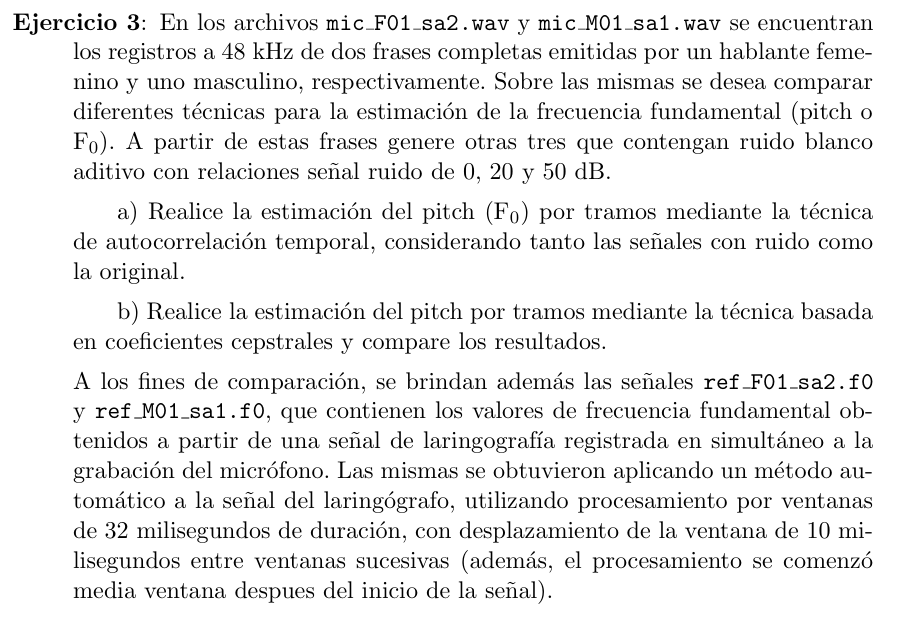

# Inciso a

In [596]:
import matplotlib.pyplot as plt
import numpy as np
import csv
from scipy.io import wavfile
from scipy.fft import fft, fftfreq, ifft, fftshift

(135000,)


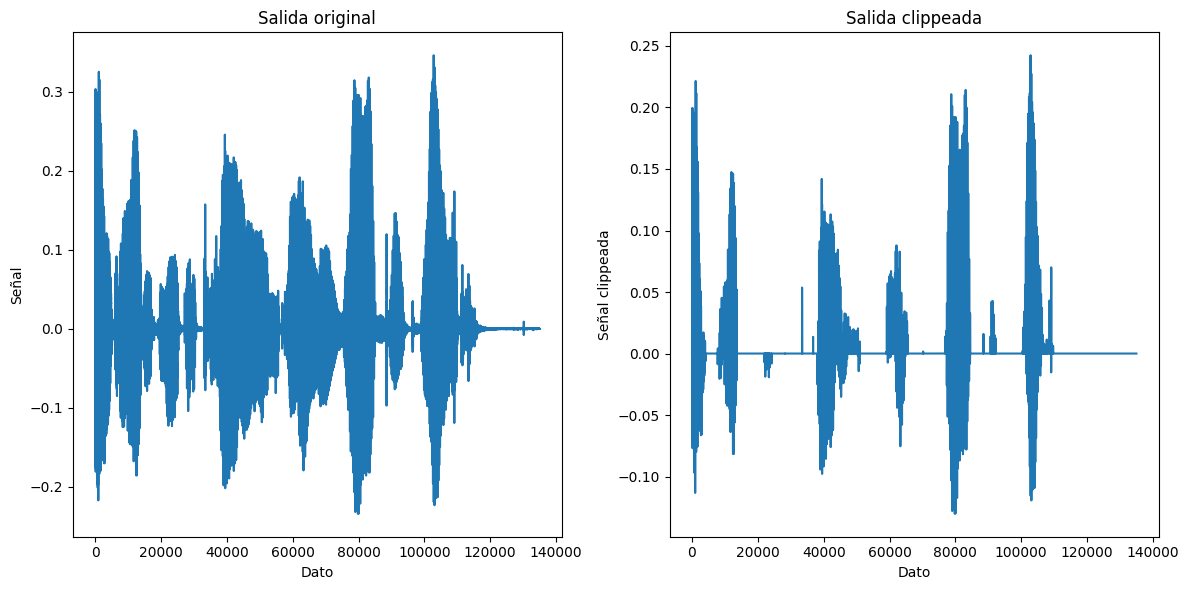

In [597]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

def agregar_ruido(x, SNR_dB):
    P_signal = np.mean(x**2)

    P_noise = P_signal / (10**(SNR_dB / 10))

    ruido = np.random.randn(len(x))  # ruido blanco N(0,1)
    ruido = ruido / np.sqrt(np.mean(ruido**2))  # normalizar potencia a 1

    ruido = ruido * np.sqrt(P_noise)  # escalar a potencia deseada

    y = x + ruido
    return y

def center_clipping(x, percentage=0.3):
    salida = np.zeros_like(x)
    c_norm = np.max(np.abs(x)) * percentage
    for i in range(len(x)):
        dato = x[i]

        if np.abs(dato) < c_norm:
          dato = 0
        elif dato > c_norm:         
          dato -= c_norm
        else:
          dato += c_norm
        salida[i] = dato
    return salida

fs, salida = wavfile.read("PDS_Datos_TP2/mic_F01_sa2.wav")
salida = salida[165000:300000] # Para voz femenina
#salida = salida[140000:315000] # Para voz masculina
N = len(salida)
print(salida.shape)

# normalizar según tipo
if salida.dtype == np.int16:
    salida = salida.astype(np.float64)
    salida /= 32768
elif salida.dtype == np.int32:
    salida = salida.astype(np.float64)
    salida /= 2147483648

# 0dB, 20dB, 50dB
salidas = [salida, agregar_ruido(salida, 20), agregar_ruido(salida, 50)]

a = 0.97
q = 0.001
for i in range(len(salidas)):
   # Remoción media
   salidas[i] -= np.mean(salidas[i])

   # Pre-énfasis
   salidas[i] = salidas[i][1:] - a * salidas[i][:-1]

   # Perturbación
   salidas[i] = salidas[i] + q * np.random.randn(len(salidas[i]))

   # Ventana
   ventana = np.hamming(len(salidas[i]))
   salidas[i] = salidas[i] * ventana
   salidas[i] /= np.max(np.abs(salidas[i]))

# Aplicamos center clipping
salidas = [center_clipping(salidas[0]), center_clipping(salidas[1]), center_clipping(salidas[2])]

frecM = 48000

plt.figure(figsize=(12,6))

dom = np.arange(0,len(salida),1) 
plt.subplot(1,2,1)
plt.title("Salida original")
plt.xlabel("Dato")
plt.ylabel("Señal")
plt.plot(dom, salida)

plt.subplot(1,2,2)
plt.title("Salida clippeada")
plt.xlabel("Dato")
plt.ylabel("Señal clippeada")
plt.plot(dom, center_clipping(salida))
plt.tight_layout()
plt.show()

In [598]:
def autocorrelacion_pesada(x, tau, q):
    x_s = x.copy()
    x_m = x.copy()
    N = len(x)

    numerador = 1/(N - np.abs(tau))
    suma_numerador = 0
    for n in range(N-1):
        if q + n < N and q + n + tau < N:
            suma_numerador += x_s[q + n] * x_s[q + n + tau]
    numerador *= suma_numerador

    denominador = 1e-10
    suma_denominador = 0
    for n in range(q, q + N - 1):
        if n+tau < N:
            suma_denominador += np.abs(x_m[n] - x_m[n+tau])
    denominador += suma_denominador

    salida = numerador / denominador
    return salida

def fast_autocorrelacion_pesada(x, tau):
    if tau == 0:
        return 0

    num = np.dot(x[:-tau], x[tau:]) / (len(x) - tau)
    den = np.sum(np.abs(x[:-tau] - x[tau:])) + 1e-10

    return num / den

arranque = 20
fin = 1000
taus = np.arange(0, fin, 1)
#q = 2

APs = []
X_picos = []

for signal in salidas:
    AP = []
    for tau in taus:
        AP.append(fast_autocorrelacion_pesada(signal, tau))
    X_picos.append(np.argmax(AP[arranque:]) + arranque)
    APs.append(AP)

Pico detectado para la señal con ruido 0 dB: 256 -> F0 = 187.5
Pico detectado para la señal con ruido 20 dB: 256 -> F0 = 187.5
Pico detectado para la señal con ruido 50 dB: 256 -> F0 = 187.5


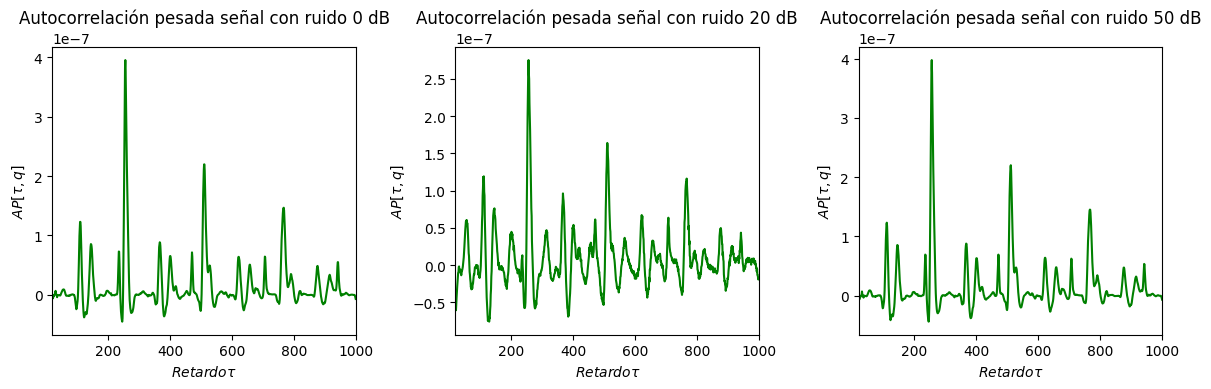

In [599]:
ruidos = ['0 dB', '20 dB', '50 dB']

plt.figure(figsize=(12,4))
for i in range(len(salidas)):
    plt.subplot(1,3,i+1)
    plt.title(f"Autocorrelación pesada señal con ruido {ruidos[i]}")
    print(f"Pico detectado para la señal con ruido {ruidos[i]}: {X_picos[i]} -> F0 = {frecM/X_picos[i]}")
    plt.ylabel("$AP[\\tau, q]$")
    plt.xlabel("$Retardo \\tau$")
    plt.xlim(arranque,fin)
    plt.plot(taus[arranque:], APs[i][arranque:], color='green')
plt.tight_layout()
plt.show()

# Inciso b

In [600]:
def extraer_coeficientes_cepstrales(vocal):
    v_tranf = fft(vocal)
    v_real = np.real(v_tranf)
    v_im = np.imag(v_tranf)
    v_norm = np.sqrt(v_real**2 + v_im**2)
    v_tranf = np.log(v_norm + 1e-10)
    v_inv = np.real(ifft(v_tranf))
    return np.array(v_inv)

coef = []
coef_filtrado = []
umbral = 300

for i in range(len(salidas)):
    datos = np.array(salidas[i])
    coeficientes = extraer_coeficientes_cepstrales(salidas[i])
    coef.append(coeficientes)
    filtrado = np.zeros_like(coeficientes)
    filtrado[: umbral] = coeficientes[: umbral] 
    filtrado[-umbral :] = coeficientes[-umbral :]
    coef_filtrado.append(filtrado)

coef = np.array(coef)
coef_filtrado = np.array(coef_filtrado)


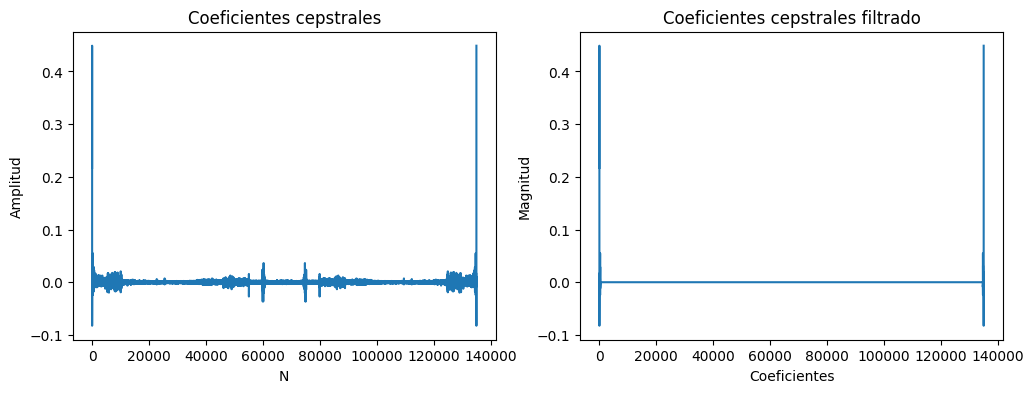

In [601]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Coeficientes cepstrales")
plt.ylabel("Amplitud")
plt.xlabel("N")
plt.plot(coef[0])

plt.subplot(1,2,2)
plt.title("Coeficientes cepstrales filtrado")
plt.plot(coef_filtrado[0])
plt.ylabel("Magnitud")
plt.xlabel("Coeficientes")
plt.show()

In [602]:
def señal_desde_coefs(coeficientes):
    fft_coef = fft(coeficientes)
    fft_exp = np.exp(fft_coef)
    return np.array(np.abs(fft_exp))

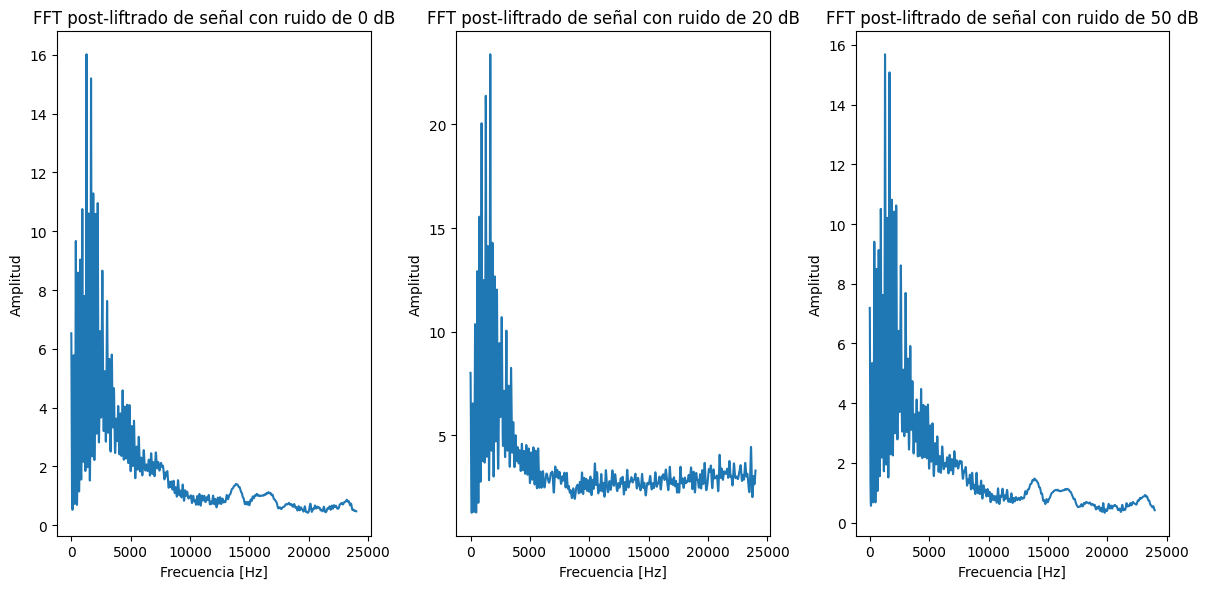

In [603]:
ffts_post_liftrado = []

frecs = fftfreq(len(salidas[0]), d=1/frecM)  # eje de frecuencias
frecs = frecs[: len(frecs)//2]

plt.figure(figsize=(12,6))
for j in range(coef_filtrado.shape[0]):
    plt.subplot(1,3,j+1)
    frecu = señal_desde_coefs(coef_filtrado[j])
    ffts_post_liftrado.append(frecu[:len(frecu)//2])

    plt.title(f"FFT post-liftrado de señal con ruido de {ruidos[j]}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Amplitud")
    plt.tight_layout()
    plt.plot(frecs,frecu[:len(frecu)//2])

plt.show()

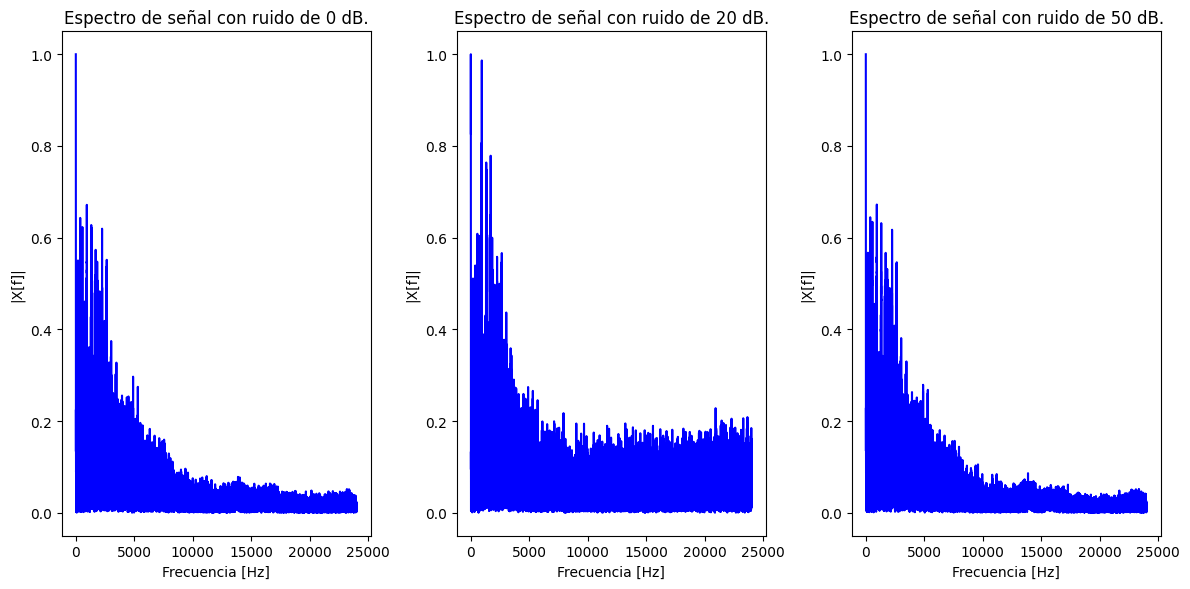

In [604]:

plt.figure(figsize=(12,6))
for j in range(len(salidas)):
    S = fft(salidas[j])
    # OBTENIENDO EL ESPECTRO DE LA SEÑAL
    S /= len(S)

    # Frecs
    S_real = np.real(S)
    S_im = np.imag(S)
    S_norm = np.sqrt(S_real**2 + S_im**2)
    S_norm = fftshift(S_norm)

    frecs = fftfreq(len(salidas[0]), d=1/frecM)  # eje de frecuencias
    frecs = fftshift(frecs)        # ordenar el eje: negativos a la izquierda

    y_xd = np.abs(S_norm)/max(np.abs(S_norm))
    # dominio de frecuencias
    plt.subplot(1,3,j+1)

    plt.plot(frecs[len(frecs)//2 :], y_xd[len(frecs)//2:], label="DFT de la señal", color="blue")
    plt.title(f"Espectro de señal con ruido de {ruidos[j]}.")
    plt.tight_layout()
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|X[f]|")

plt.show()

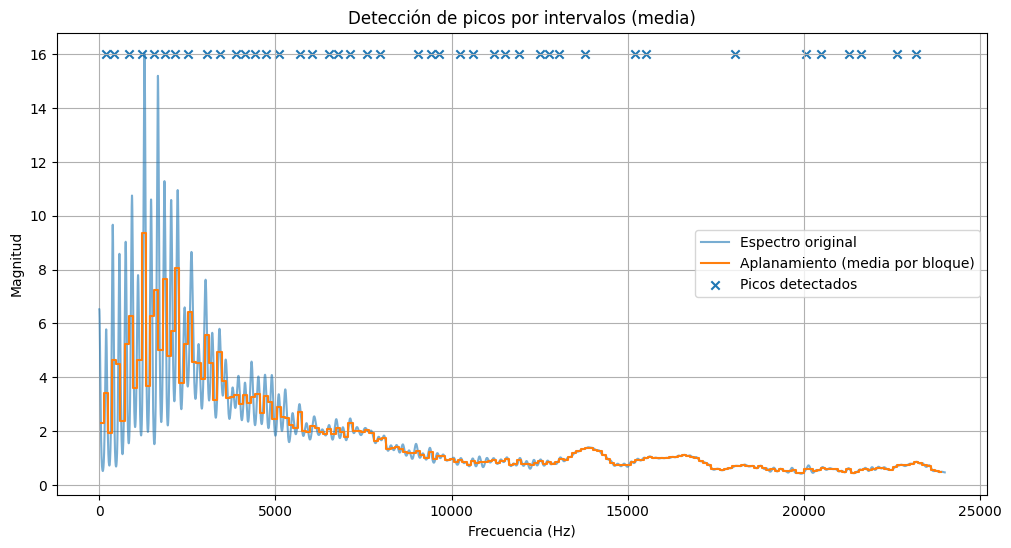

[  179.55688561   419.20310521   838.58398951  1198.05331891
  1557.52264832  1857.08042282  2156.63819732  2516.10752672
  3055.31152083  3414.78085023  3894.07328943  4133.71950903
  4433.27728354  4732.83505804  5092.30438744  5691.41993644
  6050.88926585  6530.18170505  6769.82792465  7129.29725405
  7608.58969326  7968.05902266  9046.46701087  9405.93634027
  9645.58255987 10244.69810887 10604.16743828 11203.28298728
 11502.84076178 11922.22164609 12521.33719509 12760.98341469
 13060.54118919 13779.479848   15217.35716561 15516.91494011
 18033.20024593 20070.19311254 20489.57399684 21268.42421055
 21627.89353995 22646.38997326 23185.59396736]


In [608]:
def obtener_picos(senial, cant_intervalos=100, umbral=0, frecM=8000):    
    
    frecs = fftfreq(len(salidas[0]), d=1/frecM)
    frecs = frecs[: len(frecs)//2]

    N = len(senial)
    tam_intervalo = N // cant_intervalos

    frecuencias = []
    medias = []
    frecs_intervalos = []

    for i in range(cant_intervalos):
        inicio = i * tam_intervalo
        fin = inicio + tam_intervalo
        
        intervalo = senial[inicio:fin]
        
        if len(intervalo) > 0:
            media_val = np.mean(intervalo)
            medias.append(media_val)

            centro = (inicio + fin) // 2 

            if centro < len(frecs):
                freq = frecs[centro]
            else:
                freq = frecs[-1]

            frecuencias.append(freq)
            frecs_intervalos.append(freq)

    medias = np.array(medias)
    frecs_intervalos = np.array(frecs_intervalos)

    diferencias = np.diff(medias)

    i = 0
    frecs_fund = []

    while i < len(diferencias):
        if diferencias[i] > umbral:
            indices_racha = []

            # detectar racha consecutiva
            j = i
            while j < len(diferencias) and diferencias[j] > umbral:
                indices_racha.append(j)
                j += 1

            # tomar los dos últimos de la racha
            if len(indices_racha) >= 2:
                idx1 = indices_racha[-2] + 1
                idx2 = indices_racha[-1] + 1

                freq_media = (frecuencias[idx1] + frecuencias[idx2]) / 2
                frecs_fund.append(freq_media)

            else:
                # si solo hay uno, usar ese normalmente
                idx = indices_racha[0] + 1
                frecs_fund.append(frecuencias[idx])

            i = j
        else:
            i += 1

    frecs_fund = np.array(frecs_fund)

    # ------------------ PLOT ------------------

    plt.figure(figsize=(12,6))

    # señal original
    plt.plot(frecs[:len(senial)], senial, label="Espectro original", alpha=0.6)

    # aplanamiento
    plt.step(frecs_intervalos, medias, where='mid', label="Aplanamiento (media por bloque)")

    # picos detectados
    if len(frecs_fund) > 0:
        y_picos = [np.max(senial)] * len(frecs_fund)
        plt.scatter(frecs_fund, y_picos, marker='x', label="Picos detectados")

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.title("Detección de picos por intervalos (media)")
    plt.legend()
    plt.grid()

    plt.show()

    return np.array(diferencias), frecs_fund

FRECS_FUND = []

diferencias, frecs_fund = obtener_picos(ffts_post_liftrado[0], cant_intervalos=200, umbral=5e-2, frecM=frecM)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)


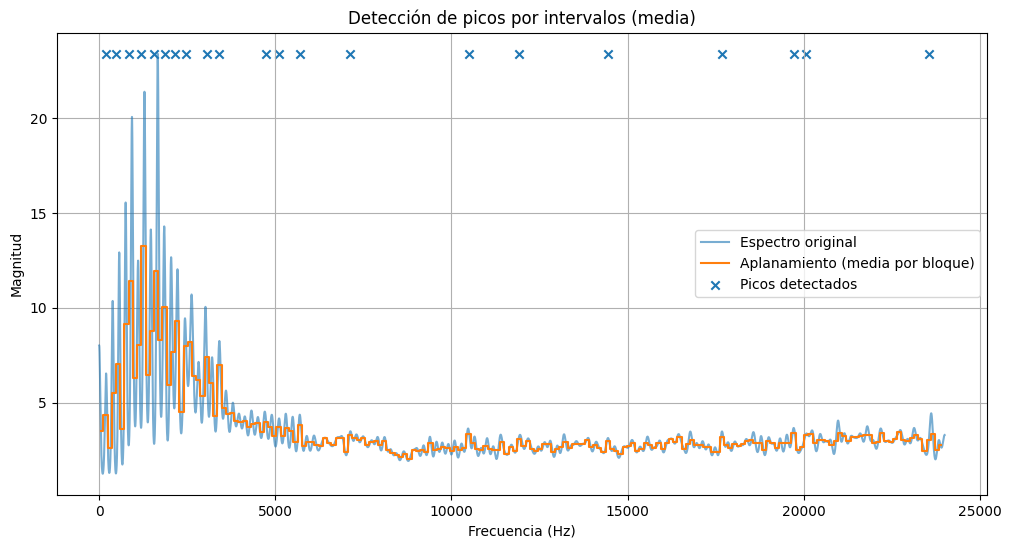

[  179.55688561   479.11466011   838.58398951  1198.05331891
  1557.52264832  1857.08042282  2156.63819732  2456.19597182
  3055.31152083  3414.78085023  4732.83505804  5092.30438744
  5691.41993644  7129.29725405 10484.34432848 11922.22164609
 14438.5069519  17673.73091653 19710.72378314 20070.19311254
 23545.06329677]


In [609]:
diferencias, frecs_fund = obtener_picos(ffts_post_liftrado[1], cant_intervalos=200, umbral=5e-1, frecM=frecM)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

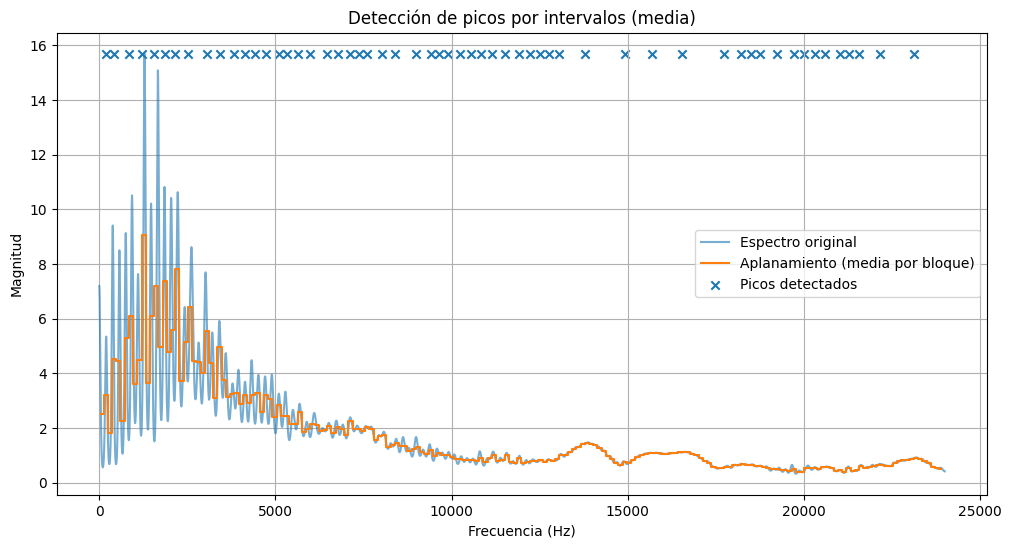

[  179.55688561   419.20310521   838.58398951  1198.05331891
  1557.52264832  1857.08042282  2156.63819732  2516.10752672
  3055.31152083  3414.78085023  3834.16173453  4133.71950903
  4433.27728354  4732.83505804  5092.30438744  5331.95060704
  5631.50838154  5990.97771095  6470.27015015  6769.82792465
  7129.29725405  7368.94347366  7608.58969326  8027.97057756
  8387.43990696  8986.55545597  9405.93634027  9645.58255987
  9885.22877947 10244.69810887 10544.25588338 10843.81365788
 11143.37143238 11502.84076178 11922.22164609 12221.77942059
 12521.33719509 12760.98341469 13060.54118919 13779.479848
 14917.79939111 15696.64960481 16535.41137342 17733.64247143
 18212.93491063 18512.49268513 18752.13890473 19231.43134394
 19710.72378314 20010.28155764 20309.83933214 20609.39710665
 21028.77799095 21268.42421055 21567.98198505 22167.09753406
 23125.68241246]


In [610]:
diferencias, frecs_fund = obtener_picos(ffts_post_liftrado[2], cant_intervalos=200, umbral=1e-5, frecM=frecM)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)